# AMI Results Wide — Exploratory Data Analysis

Explores `ami_results_wide.csv` (one row per scored annual/sustainability report) across
the 29 European P&C companies: agentic maturity, the four AMI dimension inputs,
per-function automation depth, maturity-stage mix, and how everything moves by tier and
over time.

Every chart also saves to `ami_eda_figures/` as a PNG.

Column meanings are documented separately in `ami_results_wide_dictionary.md` — this
notebook assumes that reference and focuses on the visuals.

### 0. Environment check

In [1]:
import sys
print("Python executable:", sys.executable)
for pkg in ["pandas", "numpy", "matplotlib", "seaborn"]:
    try:
        __import__(pkg)
        print(f"  {pkg:12s} OK")
    except ImportError:
        print(f"  {pkg:12s} MISSING")


Python executable: /opt/homebrew/anaconda3/envs/ml/bin/python
  pandas       OK
  numpy        OK
  matplotlib   OK
  seaborn      OK


### 1. Install packages (run once if anything is missing above)
If this errors with `externally-managed-environment`, re-run as `%pip install --break-system-packages pandas numpy matplotlib seaborn`.

In [2]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


### 2. Imports & setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

# consistent tier colours everywhere
TIER_PALETTE = {"A": "#4d7298", "B": "#66ad76", "C": "#de73aa"}

# ---- paths: resolved relative to the repo, not to any one machine ----
def _find_repo_root():
    """Walk up from the working directory until the repo layout is found."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data").is_dir() and (cand / "notebooks").is_dir():
            return cand
    return here

ROOT = _find_repo_root()
DATA    = ROOT / "data"
PROCESSED = ROOT / DATA / "processed"
FIG_DIR = ROOT / "figures" / "ami_report_eda_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"  saved -> {FIG_DIR.name}/{name}.png")

CSV_PATH = PROCESSED / "ami_results_wide.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"{CSV_PATH} not found. It is produced by notebook 01, and a copy is "
        "provided in data/. See data/README.md."
    )

print(f"Repo root: {ROOT}")
print(f"Input    : {CSV_PATH}")
print(f"Figures ->  {FIG_DIR}")
print("Setup complete.")


Repo root: /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github
Input    : /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/data/processed/ami_results_wide.csv
Figures ->  /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/figures/ami_report_eda_figures
Setup complete.


### 3. Load data & first look

In [4]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Companies: {df['company'].nunique()}   |   Years: {sorted(df['year'].unique())}")
print(f"Doc types: {df['doc_type'].unique().tolist()}")
df.head()


Shape: 86 rows x 21 columns
Companies: 29   |   Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Doc types: ['Annual Report', 'Financial Statement', 'SFCR']


,company,tier,year,doc_type,filename,tokens,agentic_share_of_automation,raw_agentic,raw_prior_gen_automation,dim_role_evolution_per10k,...,dim_governance_per10k,stage_assisted,stage_augmented,stage_frontier,automation_depth_distribution_per10k,automation_depth_underwriting_per10k,automation_depth_pricing_actuarial_per10k,automation_depth_claims_per10k,automation_depth_servicing_per10k,automation_depth_billing_per10k
0,AXA,A,2023,Annual Report,AXA annual report 2023.pdf,298560,0.56,20,16,2.48,...,3.11,469,45,16,0.03,0.00,0.03,0.00,0.00,0.00
1,AXA,A,2024,Annual Report,AXA annual report 2024.pdf,286962,0.68,23,11,2.68,...,3.87,581,49,14,0.00,0.00,0.00,0.00,0.21,0.03
2,AXA,A,2025,Annual Report,AXA annual report 2025.pdf,550822,0.79,83,22,2.60,...,3.99,1017,130,41,0.07,0.07,0.18,0.04,0.18,0.00
3,Admiral,B,2023,Annual Report,Admiral Group 2023 annual report.pdf,176269,0.30,3,7,0.85,...,0.96,307,28,43,0.00,0.06,0.00,0.00,0.00,0.00
4,Admiral,B,2024,Annual Report,Admiral Group 2024 annual report.pdf,158233,0.95,18,1,1.01,...,1.07,296,38,27,0.00,0.13,0.06,0.00,0.19,0.00


In [5]:
# column groups we'll reuse throughout
DIMENSION_COLS = ["dim_role_evolution_per10k", "dim_tech_stack_per10k", "dim_governance_per10k"]
STAGE_COLS = ["stage_assisted", "stage_augmented", "stage_frontier"]
FUNCTION_COLS = [c for c in df.columns if c.startswith("automation_depth_")]
FUNCTION_LABELS = [c.replace("automation_depth_", "").replace("_per10k", "") for c in FUNCTION_COLS]

print("Dimension columns:", DIMENSION_COLS)
print("Function columns:", FUNCTION_LABELS)


Dimension columns: ['dim_role_evolution_per10k', 'dim_tech_stack_per10k', 'dim_governance_per10k']
Function columns: ['distribution', 'underwriting', 'pricing_actuarial', 'claims', 'servicing', 'billing']


### 4. Data quality check
Missing values, coverage per company, and document-length spread — the gaps to know about *before* comparing companies.

In [6]:
print("=== Missing values per column ===")
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() else "No missing values.")

print("\n=== Rows (documents) per company ===")
coverage = df.groupby(["tier", "company"]).size().rename("n_documents").reset_index()
print(coverage.to_string(index=False))

print("\n=== Company x year coverage (1 = present) ===")
pivot_cov = df.assign(present=1).pivot_table(
    index="company", columns="year", values="present", aggfunc="max", fill_value=0
).astype(int)
display(pivot_cov)


=== Missing values per column ===
No missing values.

=== Rows (documents) per company ===
tier                   company  n_documents
   A                       AXA            3
   A                   Allianz            3
   A                     Aviva            3
   A                  Generali            3
   A                    Mapfre            3
   A                 Munich Re            3
   A                  NN Group            3
   A                  Swiss Re            3
   A                    Talanx            3
   A                    Unipol            3
   A                    Zurich            3
   B                   Admiral            3
   B                     Ageas            3
   B                   Beazley            3
   B                Gjensidige            3
   B          Helvetia Baloise            3
   B                    Hiscox            3
   B                     Sampo            3
   B                      Tryg            3
   B                       VI

year,2022,2023,2024,2025
company,,,,
AXA,0,1,1,1
Admiral,0,1,1,1
Ageas,0,1,1,1
Allianz,0,1,1,1
Alm Brand Group,0,1,1,1
Aviva,0,1,1,1
Beazley,0,1,1,1
Bolttech,0,1,1,0
Coface,0,1,1,1


  saved -> ami_report_eda_figures/01_document_length.png


/var/folders/rd/281l0k4d6_s7p_d790_z55180000gn/T/ipykernel_20479/1446794179.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="tier", y="tokens", palette=TIER_PALETTE, ax=axes[1],


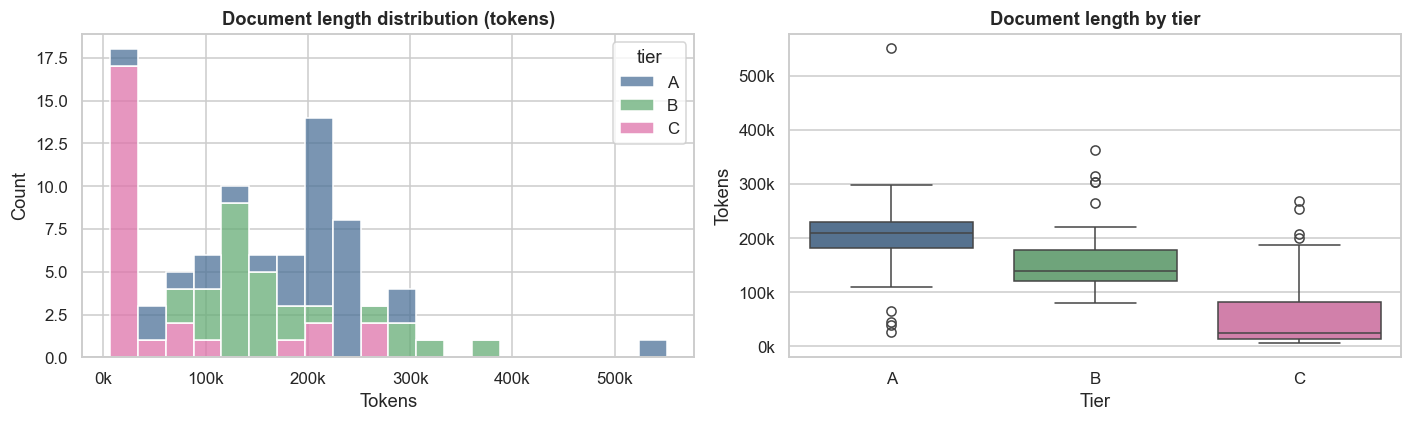

In [7]:
# document length distribution — the per10k denominator, and a known sensitivity in the scorer
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="tokens", hue="tier", palette=TIER_PALETTE,
             bins=20, ax=axes[0], multiple="stack")
axes[0].set_title("Document length distribution (tokens)")
axes[0].set_xlabel("Tokens")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

sns.boxplot(data=df, x="tier", y="tokens", palette=TIER_PALETTE, ax=axes[1],
            order=["A", "B", "C"])
axes[1].set_title("Document length by tier")
axes[1].set_xlabel("Tier"); axes[1].set_ylabel("Tokens")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

plt.tight_layout()
save(fig, "01_document_length")
plt.show()


### 5. Headline metric — agentic share of automation
Of all automation-related language in each report, what share was genuinely *agentic* rather than legacy automation. This is the gate-adjusted maturity indicator.

Companies with <3 years of report coverage (interpret cautiously): ['Bolttech']
  saved -> ami_report_eda_figures/02_agentic_share_by_company.png


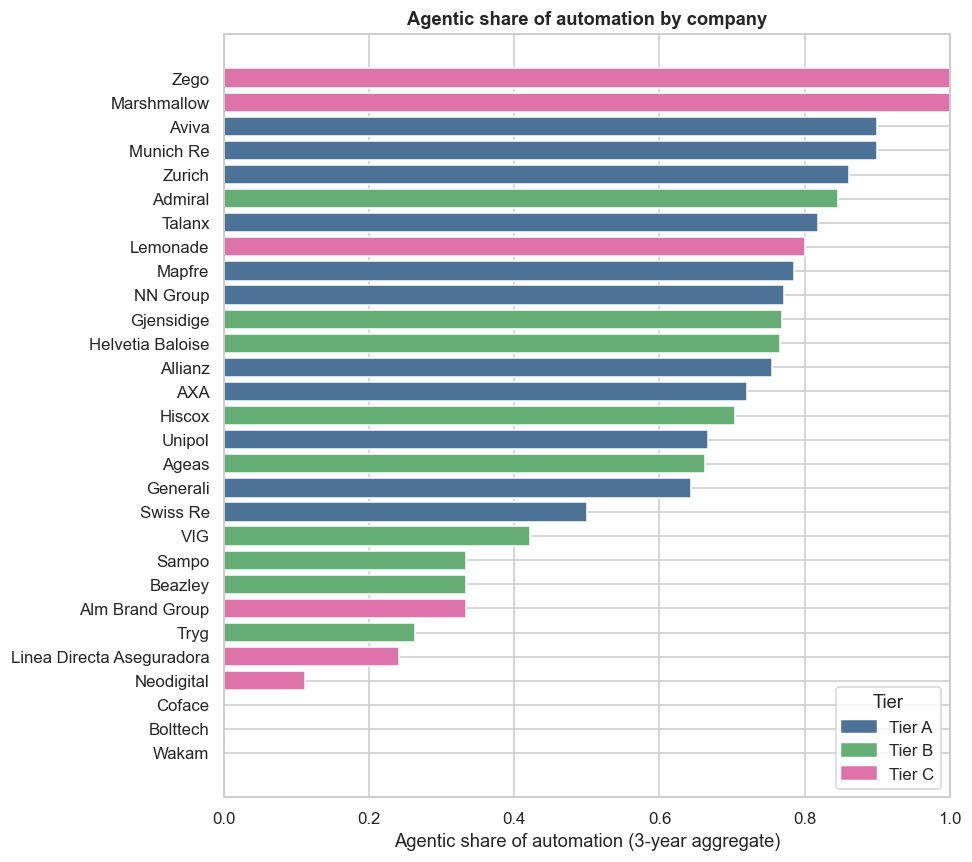

In [8]:
# aggregate across ALL available years per company (sum raw hits, then take the
# ratio) -- NOT the most recent document only, and NOT an average of yearly ratios,
# since that would over-weight years with tiny/zero denominators
def _token_weighted_mean(g, cols):
    w = g["tokens"]
    return pd.Series({c: (g[c] * w).sum() / w.sum() if w.sum() else 0.0 for c in cols})

agg = df.groupby("company", as_index=False).agg(
    tier=("tier", "first"),
    n_years=("year", "nunique"),
    years_used=("year", lambda s: sorted(s.unique().tolist())),
    tokens_total=("tokens", "sum"),
    raw_agentic=("raw_agentic", "sum"),
    raw_prior_gen_automation=("raw_prior_gen_automation", "sum"),
)
agg["agentic_share_of_automation"] = (
    agg["raw_agentic"] / (agg["raw_agentic"] + agg["raw_prior_gen_automation"]).replace(0, np.nan)
).fillna(0)  # true 0/0 (no automation-dimension language detected at all) stays 0, not NaN

# per-10k rates aren't raw counts, so aggregate as a token-weighted average across years
_weighted_cols = DIMENSION_COLS + FUNCTION_COLS
_w_agg = df.groupby("company").apply(lambda g: _token_weighted_mean(g, _weighted_cols)).reset_index()
agg = agg.merge(_w_agg, on="company", how="left")

print(f"Companies with <3 years of report coverage (interpret cautiously): "
      f"{agg[agg['n_years']<3]['company'].tolist()}")

agg_sorted = agg.sort_values("agentic_share_of_automation", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = agg_sorted["tier"].map(TIER_PALETTE)
ax.barh(agg_sorted["company"], agg_sorted["agentic_share_of_automation"], color=colors)
ax.set_xlabel("Agentic share of automation (3-year aggregate)")
ax.set_title("Agentic share of automation by company")
ax.set_xlim(0, 1)
# tier legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=f"Tier {k}") for k, v in TIER_PALETTE.items()],
          loc="lower right", title="Tier")
plt.tight_layout()
save(fig, "02_agentic_share_by_company")
plt.show()


  saved -> ami_report_eda_figures/03_raw_mention_counts.png


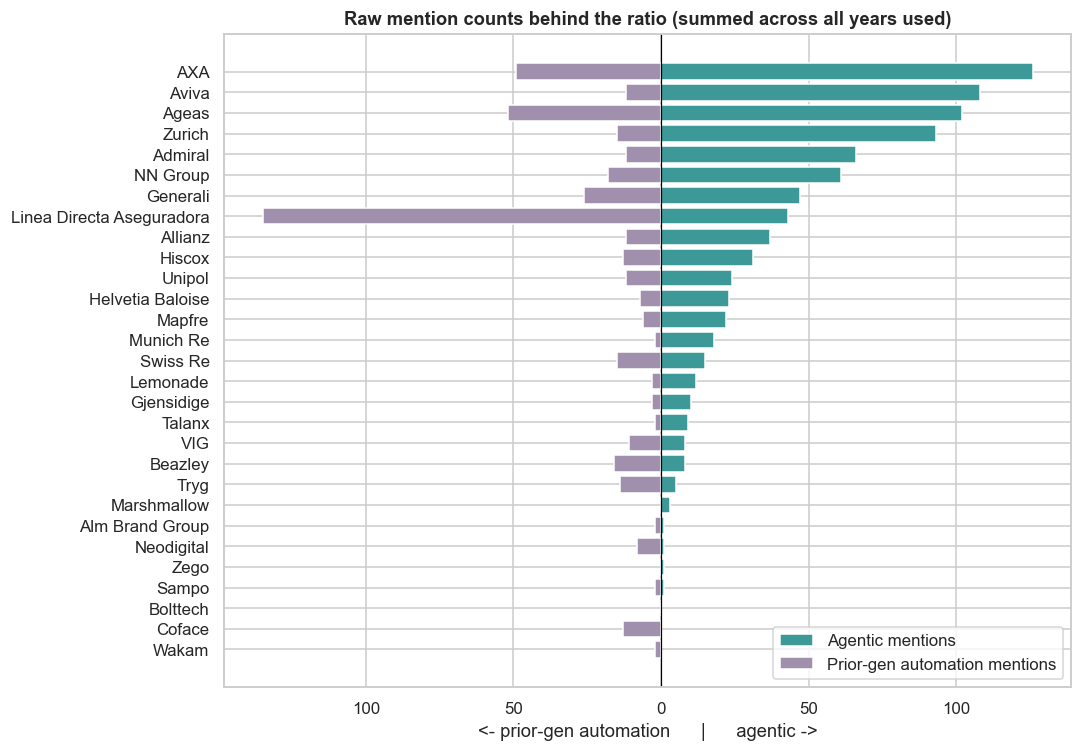

Why this matters: agentic_share is a RATIO. A company with few total mentions
can post a high share off a tiny base — this chart shows the denominator.


In [9]:
# the raw counts BEHIND the ratio — context so a high share off a tiny base is visible
# (now summed across all years used, not just the latest report)
fig, ax = plt.subplots(figsize=(10, 7))
lat = agg.sort_values("raw_agentic")
ax.barh(lat["company"], lat["raw_agentic"], color="#3c9997", label="Agentic mentions")
ax.barh(lat["company"], -lat["raw_prior_gen_automation"], color="#a190ad",
        label="Prior-gen automation mentions")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Raw mention counts behind the ratio (summed across all years used)")
ax.set_xlabel("<- prior-gen automation      |      agentic ->")
ax.legend(loc="lower right")
# show absolute values on the tick labels
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(int(x))}"))
plt.tight_layout()
save(fig, "03_raw_mention_counts")
plt.show()

print("Why this matters: agentic_share is a RATIO. A company with few total mentions")
print("can post a high share off a tiny base — this chart shows the denominator.")


### 6. How maturity differs by tier

  saved -> ami_report_eda_figures/04_agentic_share_by_tier.png


/var/folders/rd/281l0k4d6_s7p_d790_z55180000gn/T/ipykernel_20479/17882763.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="tier", y="agentic_share_of_automation",


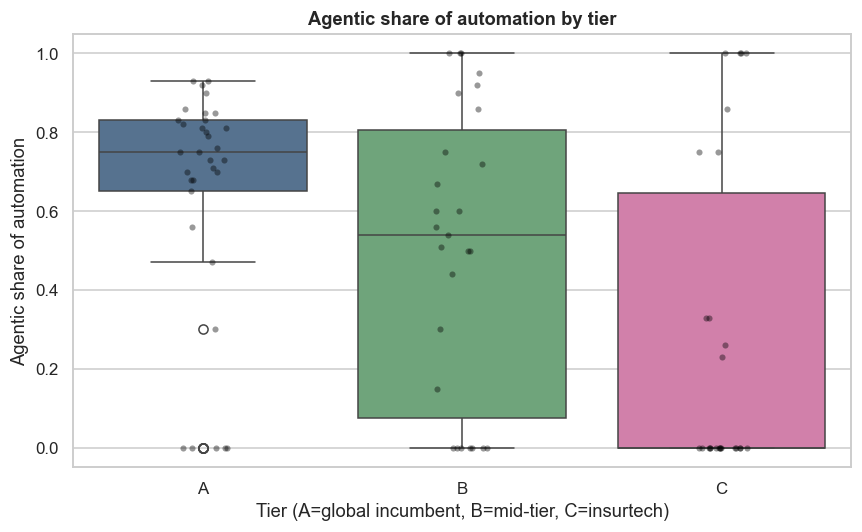

      count   mean  median    std
tier                             
A        33  0.639    0.75  0.303
B        27  0.499    0.54  0.367
C        26  0.289    0.00  0.402


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="tier", y="agentic_share_of_automation",
            palette=TIER_PALETTE, order=["A", "B", "C"], ax=ax)
sns.stripplot(data=df, x="tier", y="agentic_share_of_automation",
              order=["A", "B", "C"], color="black", alpha=0.4, size=4, ax=ax)
ax.set_title("Agentic share of automation by tier")
ax.set_xlabel("Tier (A=global incumbent, B=mid-tier, C=insurtech)")
ax.set_ylabel("Agentic share of automation")
plt.tight_layout()
save(fig, "04_agentic_share_by_tier")
plt.show()

print(df.groupby("tier")["agentic_share_of_automation"]
        .agg(["count", "mean", "median", "std"]).round(3).to_string())


### 7. The three dimension inputs
Role-evolution, tech-stack, and governance densities (per 10k tokens). These feed three of the four AMI dimensions.

  saved -> ami_report_eda_figures/05_dimensions_by_tier.png


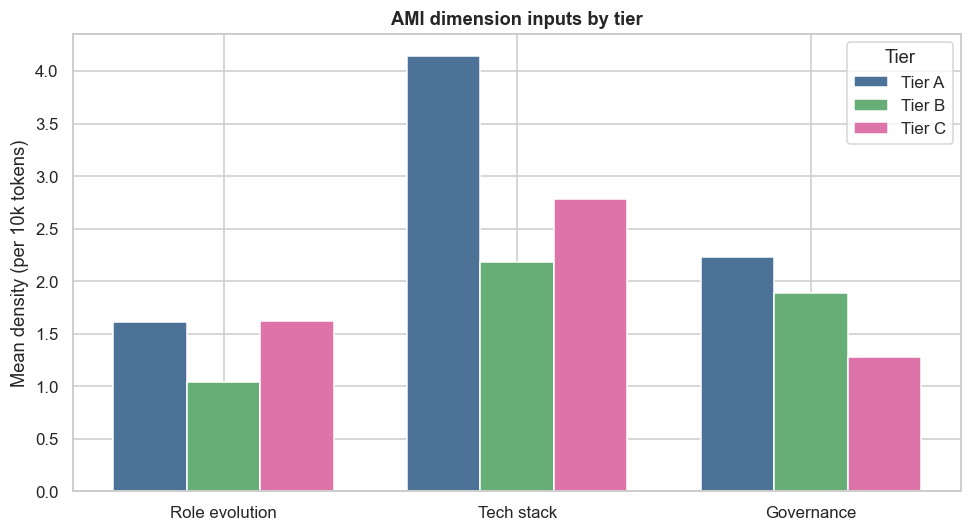

In [11]:
# mean dimension densities by tier — grouped bars
dim_by_tier = df.groupby("tier")[DIMENSION_COLS].mean().reindex(["A", "B", "C"])
nice_names = ["Role evolution", "Tech stack", "Governance"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(nice_names))
width = 0.25
for i, tier in enumerate(["A", "B", "C"]):
    ax.bar(x + (i-1)*width, dim_by_tier.loc[tier], width,
           label=f"Tier {tier}", color=TIER_PALETTE[tier])
ax.set_xticks(x); ax.set_xticklabels(nice_names)
ax.set_ylabel("Mean density (per 10k tokens)")
ax.set_title("AMI dimension inputs by tier")
ax.legend(title="Tier")
plt.tight_layout()
save(fig, "05_dimensions_by_tier")
plt.show()


  saved -> ami_report_eda_figures/06_dimension_heatmap.png


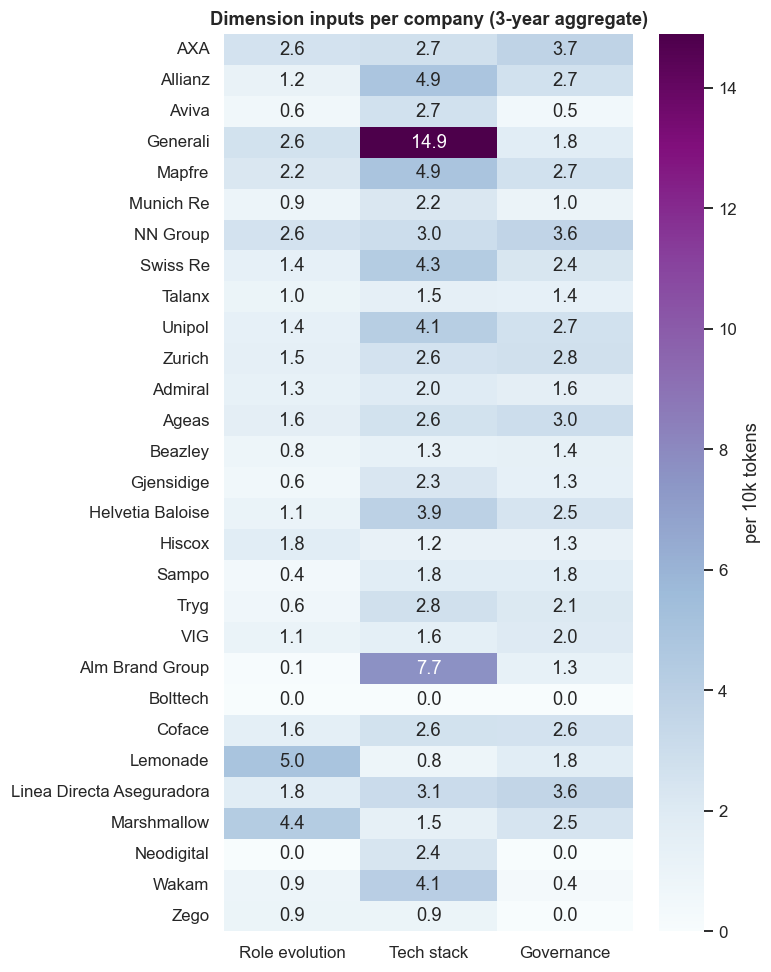

In [12]:
# per-company profile across the 3 dimensions (3-year aggregate) — heatmap
dim_matrix = agg.set_index("company")[DIMENSION_COLS].copy()
dim_matrix.columns = nice_names
dim_matrix = dim_matrix.loc[agg.sort_values("tier")["company"]]

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(dim_matrix, annot=True, fmt=".1f", cmap="BuPu",
            cbar_kws={"label": "per 10k tokens"}, ax=ax)
ax.set_title("Dimension inputs per company (3-year aggregate)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
save(fig, "06_dimension_heatmap")
plt.show()


### 8. Per-function automation depth
Where in the insurance value chain is the agentic language concentrated? Claims and underwriting are usually the front-runners.

  saved -> ami_report_eda_figures/07_function_depth_by_tier.png


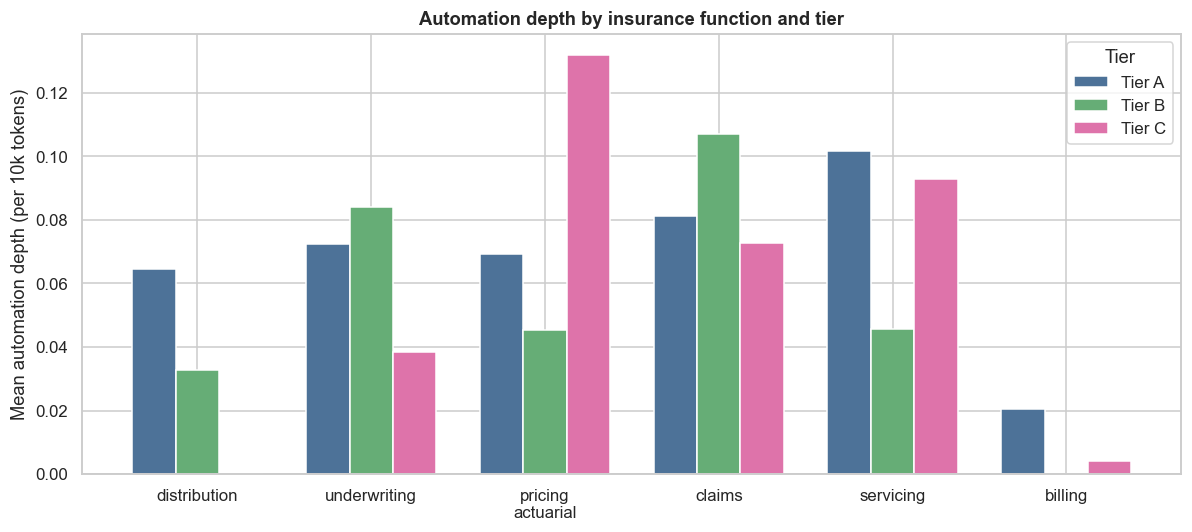

In [13]:
# mean automation depth per function, per tier
func_by_tier = df.groupby("tier")[FUNCTION_COLS].mean().reindex(["A", "B", "C"])
func_by_tier.columns = FUNCTION_LABELS

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(FUNCTION_LABELS))
width = 0.25
for i, tier in enumerate(["A", "B", "C"]):
    ax.bar(x + (i-1)*width, func_by_tier.loc[tier], width,
           label=f"Tier {tier}", color=TIER_PALETTE[tier])
ax.set_xticks(x)
ax.set_xticklabels([l.replace("_", "\n") for l in FUNCTION_LABELS])
ax.set_ylabel("Mean automation depth (per 10k tokens)")
ax.set_title("Automation depth by insurance function and tier")
ax.legend(title="Tier")
plt.tight_layout()
save(fig, "07_function_depth_by_tier")
plt.show()


  saved -> ami_report_eda_figures/08_function_heatmap.png


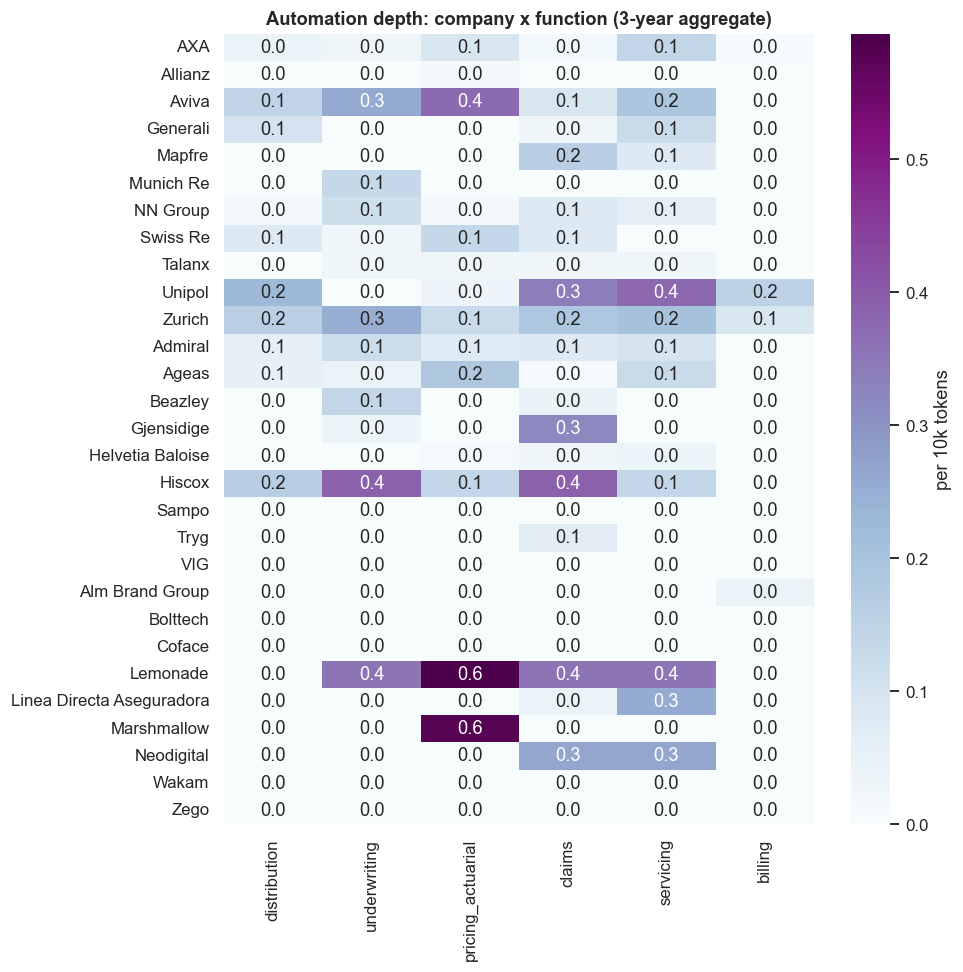

Reminder: normalized by TOTAL document tokens, not per-function text volume.
A barely-discussed function reads low here even if its few mentions are agentic.


In [14]:
# company x function heatmap (3-year aggregate) — the granular per-function view
func_matrix = agg.set_index("company")[FUNCTION_COLS].copy()
func_matrix.columns = FUNCTION_LABELS
func_matrix = func_matrix.loc[agg.sort_values(["tier", "company"])["company"]]

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(func_matrix, annot=True, fmt=".1f", cmap="BuPu",
            cbar_kws={"label": "per 10k tokens"}, ax=ax)
ax.set_title("Automation depth: company x function (3-year aggregate)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
save(fig, "08_function_heatmap")
plt.show()

print("Reminder: normalized by TOTAL document tokens, not per-function text volume.")
print("A barely-discussed function reads low here even if its few mentions are agentic.")


### 9. Maturity-stage mix
Assisted → Augmented → Frontier. **These three columns are raw counts, not per-10k**, so we normalize by tokens here before comparing — longer reports would otherwise look more mature purely from length.

  saved -> ami_report_eda_figures/09_maturity_stage_mix.png


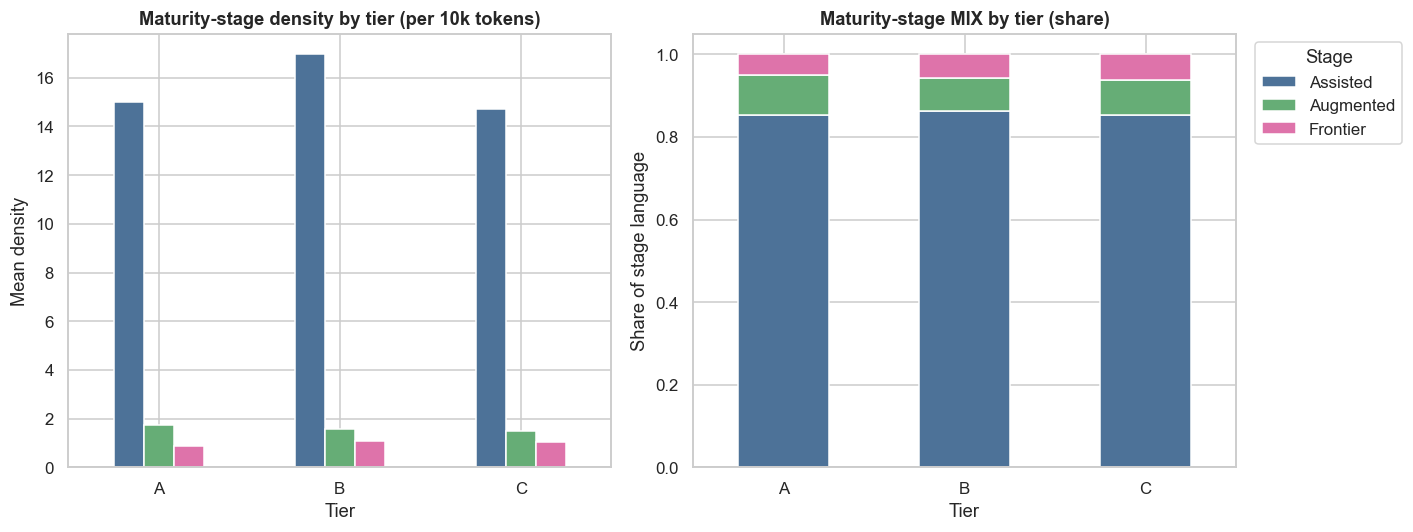

In [15]:
# normalize stage counts per 10k tokens (the dictionary flags these as un-normalized)
stage_norm = df.copy()
for col in STAGE_COLS:
    stage_norm[col + "_per10k"] = stage_norm[col] / stage_norm["tokens"] * 10000

stage_norm_cols = [c + "_per10k" for c in STAGE_COLS]
stage_by_tier = stage_norm.groupby("tier")[stage_norm_cols].mean().reindex(["A", "B", "C"])
stage_by_tier.columns = ["Assisted", "Augmented", "Frontier"]

# stacked bars showing the stage MIX per tier
stage_share = stage_by_tier.div(stage_by_tier.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
stage_by_tier.plot(kind="bar", ax=axes[0], legend=False,
                   color=TIER_PALETTE.values())
axes[0].set_title("Maturity-stage density by tier (per 10k tokens)")
axes[0].set_xlabel("Tier"); axes[0].set_ylabel("Mean density")
axes[0].tick_params(axis="x", rotation=0)

stage_share.plot(kind="bar", stacked=True, ax=axes[1],
                 color=TIER_PALETTE.values())
axes[1].set_title("Maturity-stage MIX by tier (share)")
axes[1].set_xlabel("Tier"); axes[1].set_ylabel("Share of stage language")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save(fig, "09_maturity_stage_mix")
plt.show()


### 10. Trends over time
Does agentic maturity rise across report years? Averaged by tier to smooth single-company noise.

  saved -> ami_report_eda_figures/10_trend_over_time.png


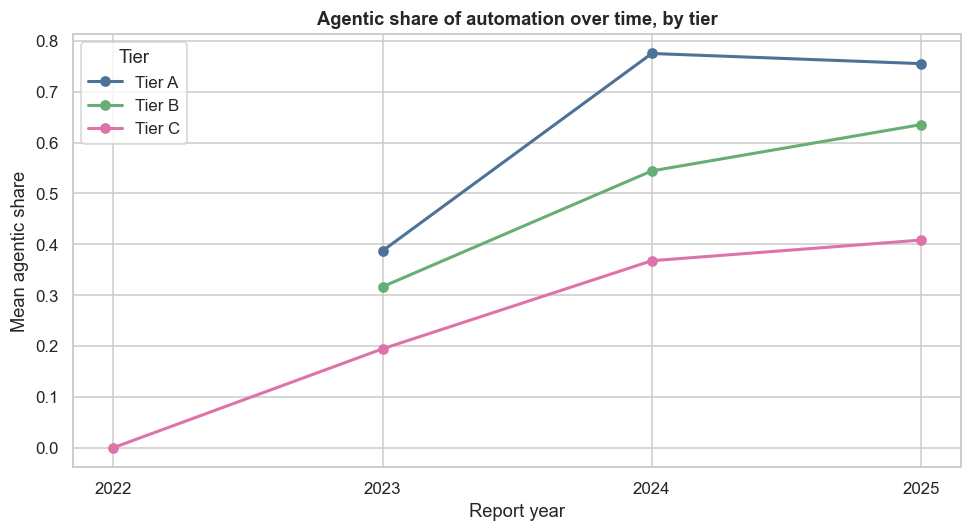

Documents behind each point (sparse cells = noisy averages):
tier   A  B  C
year          
2022   0  0  2
2023  11  9  9
2024  11  9  9
2025  11  9  6


In [16]:
year_tier = df.groupby(["year", "tier"])["agentic_share_of_automation"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for tier in ["A", "B", "C"]:
    sub = year_tier[year_tier["tier"] == tier]
    ax.plot(sub["year"], sub["agentic_share_of_automation"],
            marker="o", linewidth=2, label=f"Tier {tier}", color=TIER_PALETTE[tier])
ax.set_title("Agentic share of automation over time, by tier")
ax.set_xlabel("Report year"); ax.set_ylabel("Mean agentic share")
ax.set_xticks(sorted(df["year"].unique()))
ax.legend(title="Tier")
plt.tight_layout()
save(fig, "10_trend_over_time")
plt.show()

# note the caveat about uneven year coverage
n_per_year_tier = df.groupby(["year", "tier"]).size().unstack(fill_value=0)
print("Documents behind each point (sparse cells = noisy averages):")
print(n_per_year_tier.to_string())


### 11. How do the signals relate to each other?
Correlations among the maturity metrics — do the dimensions move together, or capture different things?

  saved -> ami_report_eda_figures/11_correlation_matrix.png


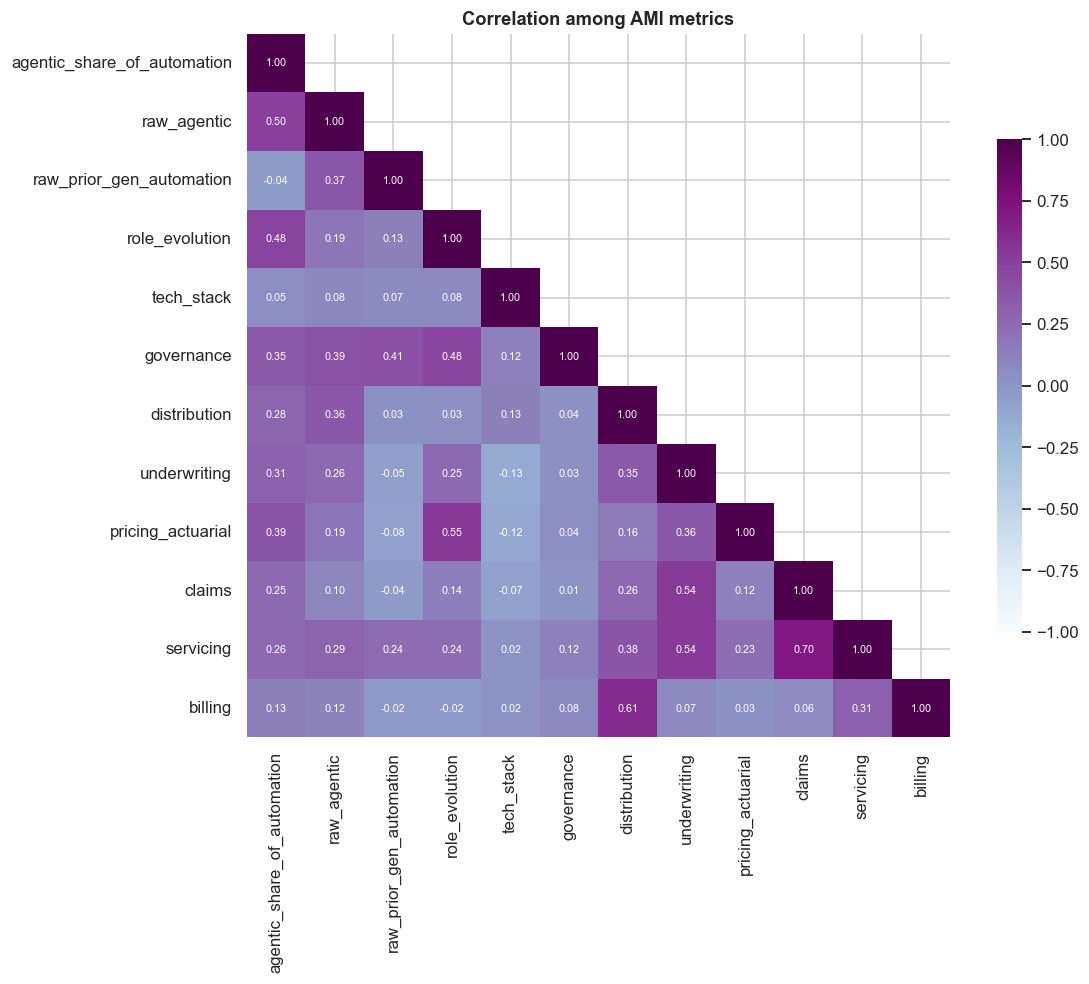

In [17]:
corr_cols = (["agentic_share_of_automation", "raw_agentic", "raw_prior_gen_automation"]
             + DIMENSION_COLS + FUNCTION_COLS)
corr = df[corr_cols].corr()

# tidy labels
label_map = {c: c.replace("automation_depth_", "").replace("_per10k", "").replace("dim_", "")
             for c in corr_cols}
corr = corr.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="BuPu", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation among AMI metrics")
plt.tight_layout()
save(fig, "11_correlation_matrix")
plt.show()


  saved -> ami_report_eda_figures/12_length_bias_check.png


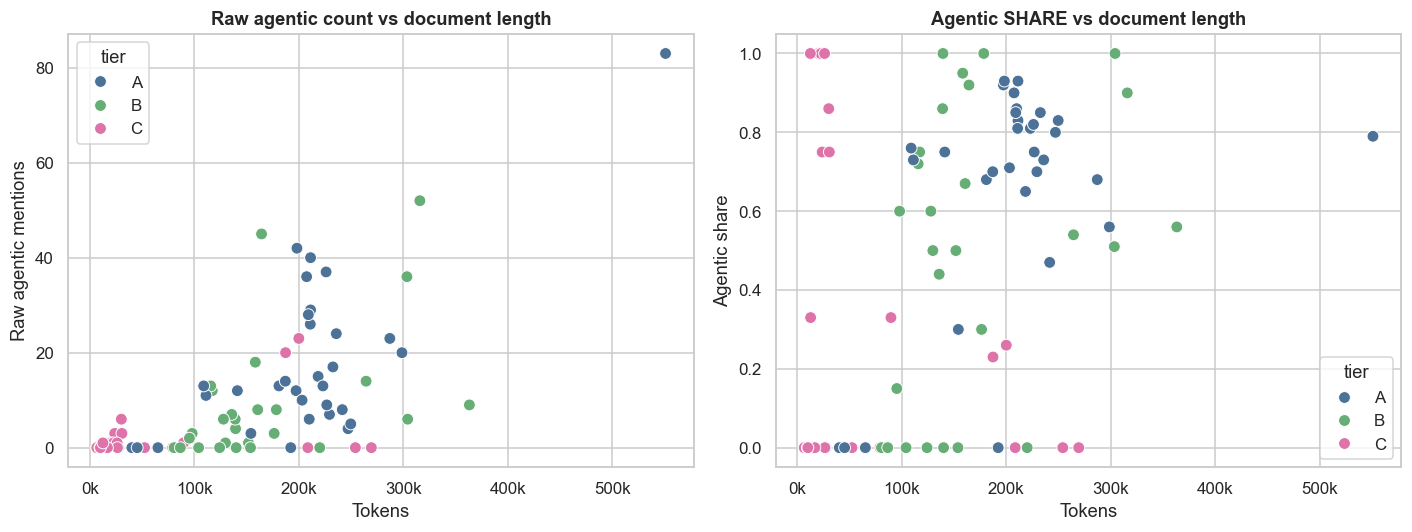

If raw counts rise with length but the SHARE stays flat, the ratio is doing its
job of controlling for document length. Worth confirming visually here.


In [18]:
# scatter: does report length bias the agentic signal? (a known scorer sensitivity)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="tokens", y="raw_agentic", hue="tier",
                palette=TIER_PALETTE, ax=axes[0], s=60)
axes[0].set_title("Raw agentic count vs document length")
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Raw agentic mentions")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

sns.scatterplot(data=df, x="tokens", y="agentic_share_of_automation", hue="tier",
                palette=TIER_PALETTE, ax=axes[1], s=60)
axes[1].set_title("Agentic SHARE vs document length")
axes[1].set_xlabel("Tokens"); axes[1].set_ylabel("Agentic share")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

plt.tight_layout()
save(fig, "12_length_bias_check")
plt.show()

print("If raw counts rise with length but the SHARE stays flat, the ratio is doing its")
print("job of controlling for document length. Worth confirming visually here.")


### 12. Summary tables to export

In [19]:
# clean summary tables for the write-up / slides
summary_by_company = (agg[["company", "tier", "n_years", "agentic_share_of_automation"]
                      + DIMENSION_COLS]
                      .sort_values(["tier", "agentic_share_of_automation"],
                                   ascending=[True, False])
                      .round(2))
summary_by_company.to_csv(FIG_DIR / "summary_by_company.csv", index=False)
print("=== 3-year aggregate summary by company ===")
display(summary_by_company)

summary_by_tier = df.groupby("tier").agg(
    n_documents=("filename", "count"),
    n_companies=("company", "nunique"),
    mean_agentic_share=("agentic_share_of_automation", "mean"),
    mean_role_evolution=("dim_role_evolution_per10k", "mean"),
    mean_tech_stack=("dim_tech_stack_per10k", "mean"),
    mean_governance=("dim_governance_per10k", "mean"),
).round(2)
summary_by_tier.to_csv(FIG_DIR / "summary_by_tier.csv")
print("\n=== Summary by tier (per-document, all years -- unaffected by aggregation choice) ===")
display(summary_by_tier)

print(f"\nAll figures + summary tables saved to: {FIG_DIR}")


=== 3-year aggregate summary by company ===


,company,tier,n_years,agentic_share_of_automation,dim_role_evolution_per10k,dim_tech_stack_per10k,dim_governance_per10k
5,Aviva,A,3,0.90,0.62,2.68,0.47
17,Munich Re,A,3,0.90,0.92,2.23,1.04
28,Zurich,A,3,0.86,1.50,2.61,2.77
22,Talanx,A,3,0.82,0.97,1.51,1.39
15,Mapfre,A,3,0.79,2.25,4.95,2.70
18,NN Group,A,3,0.77,2.57,2.99,3.64
3,Allianz,A,3,0.76,1.20,4.89,2.69
0,AXA,A,3,0.72,2.59,2.74,3.73
24,Unipol,A,3,0.67,1.40,4.15,2.72
9,Generali,A,3,0.64,2.63,14.90,1.78



=== Summary by tier (per-document, all years -- unaffected by aggregation choice) ===


,n_documents,n_companies,mean_agentic_share,mean_role_evolution,mean_tech_stack,mean_governance
tier,,,,,,
A,33,11,0.64,1.61,4.15,2.23
B,27,9,0.50,1.04,2.18,1.89
C,26,9,0.29,1.62,2.78,1.28



All figures + summary tables saved to: /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/figures/ami_report_eda_figures


### Reading these results — caveats for the team

- **`agentic_share_of_automation` is a ratio among automation mentions**, not a share of
  the whole report. Pair it with the raw-count chart (section 5) so a high share off a
  tiny base is visible.
- **Maturity-stage columns were raw counts** — normalized per-10k here (section 9), but
  the underlying CSV is not. Don't compare the raw `stage_*` columns across companies of
  different report lengths.
- **Per-function depth is normalized by total document tokens**, so a function that's
  barely discussed reads low even if its few mentions are heavily agentic (section 8).
- **This is annual-report language** — stated positioning, not audited deployment. It's
  one evidence source among several in the AMI.
- **Uneven year/company coverage** (section 4) makes some tier-year averages thin —
  check the counts before over-reading a trend line.